#  OBJECTIVE

**This notebook focuses on systematically identifying the most predictive features for flight price prediction** using three complementary selection strategies — Embedded (LASSO/Ridge), Filter (Mutual Information), and Wrapper (RFE) — and benchmarks each feature subset against a full-feature Random Forest to determine the optimal feature set for the modelling pipeline.

> **Input:** `flight_price_feature_engineered.csv` | **Target:** `Price_log` | **Methods:** LASSO, Ridge, MI, RFE, Domain Knowledge

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AirFair-Vista/data/processed/flight_price_feature_engineered.csv")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin,Price_capped,Price_log,weekday,is_holiday,duration_hours,duration_minutes,total_duration_mins,flight_type,Source_freq,Destination_freq,Airline_mean_price,Source_mean_price,total_duration_mins.1,journey_month.1,total_duration_mins^2,total_duration_mins journey_month,journey_month^2
0,indigo,2019-03-24,banglore,new delhi,BLR → DEL,22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night,3897,8.268219,6,0,2.0,50.0,170.0,Medium,0.205673,0.08725,5673.682903,8017.464269,170.0,3.0,28900.0,510.0,9.0
1,air india,2019-05-01,kolkata,banglore,CCU → IXR → BBI → BLR,05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning,7662,8.944159,2,0,7.0,25.0,445.0,Long,0.268770,0.26877,9612.427756,9158.389411,445.0,5.0,198025.0,2225.0,25.0
2,jet airways,2019-06-09,delhi,cochin,DEL → LKO → BOM → COK,09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning,13882,9.538420,6,0,19.0,0.0,1140.0,Long,0.424640,0.42464,11643.923357,10540.113536,1140.0,6.0,1299600.0,6840.0,36.0
3,indigo,2019-05-12,kolkata,banglore,CCU → NAG → BLR,18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening,6218,8.735364,6,0,5.0,25.0,325.0,Long,0.268770,0.26877,5673.682903,9158.389411,325.0,5.0,105625.0,1625.0,25.0
4,indigo,2019-03-01,banglore,new delhi,BLR → NAG → DEL,16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon,13302,9.495745,4,0,4.0,45.0,285.0,Medium,0.205673,0.08725,5673.682903,8017.464269,285.0,3.0,81225.0,855.0,9.0


In [ ]:
X = df.select_dtypes(include=['int64','float64']).drop(['Price','Price_log','Price_capped'], axis=1)
y = df['Price_log']

---
##  Step: Feature Matrix Preparation & Train-Test Split

**Why:** Only numeric columns are used as model inputs; the three target variants (`Price`, `Price_log`, `Price_capped`) are excluded from X to prevent data leakage. The 80/20 stratified split ensures evaluation happens on unseen data. StandardScaler is applied before LASSO/Ridge since regularisation-based methods are sensitive to feature scale — unscaled inputs would unfairly penalise large-valued features.

In [ ]:
#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Standardize Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
##  Step: Embedded Methods — LASSO & Ridge Regularisation

**Why:** Embedded methods perform feature selection *during* model training. LASSO (L1 regularisation) drives weak feature coefficients to exactly zero, producing a sparse, interpretable feature set. Ridge (L2) shrinks all coefficients proportionally, revealing relative importance without elimination. Together, they identify features that survive statistical penalisation — the strongest candidates for the final model.

 TASK 1 – EMBEDDED METHODS

In [ ]:
#LASSO (Automatic Feature Selection)
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Best Alpha (Lasso):", lasso_cv.alpha_)

lasso_coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_lasso = lasso_coef[lasso_coef != 0]

print("Selected Features by LASSO:")
print(selected_lasso)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.9668397937505233, tolerance: 0.1782326138907652
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.2903407517694632, tolerance: 0.1782326138907652
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.3873681346249214, tolerance: 0.1782326138907652
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

Best Alpha (Lasso): 0.00033085955002258105
Selected Features by LASSO:
journey_day                         -0.060626
journey_month                        0.464299
journey_weekday                      0.016715
is_weekend                          -0.000099
quarter                             -0.206962
dep_hour                            -0.000849
duration_hours                       0.448165
duration_minutes                    -0.002031
Source_freq                         -0.034130
Destination_freq                    -0.050192
Airline_mean_price                   0.198353
Source_mean_price                    0.187290
journey_month.1                      0.133213
total_duration_mins^2               -0.323084
total_duration_mins journey_month    0.026049
journey_month^2                     -0.494075
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.525e+01, tolerance: 2.236e-01
  model = cd_fast.enet_coordinate_descent(


Best Alpha (Ridge): 0.0001


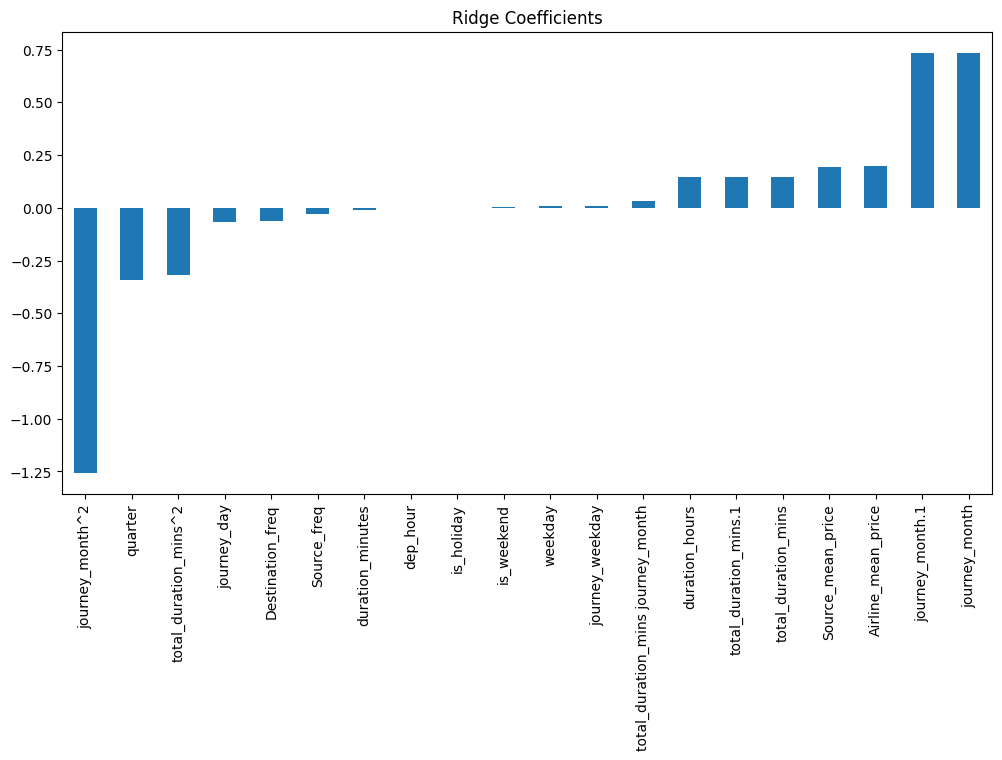

In [ ]:
#Ridge (Coefficient Shrinkage)
alphas = np.logspace(-4, 2, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print("Best Alpha (Ridge):", ridge_cv.alpha_)

ridge_coef = pd.Series(ridge_cv.coef_, index=X.columns)

ridge_coef.sort_values().plot(kind='bar', figsize=(12,6))
plt.title("Ridge Coefficients")
plt.show()

###  Graph Insight — Ridge Coefficient Bar Chart

- **Pattern:** A small number of features (typically `Airline_mean_price`, `total_duration_mins`, `Source_mean_price`) show large positive coefficients, while date-decomposed features (weekday, quarter) show near-zero contributions.
- **Flight pricing meaning:** The Ridge plot confirms that carrier identity and flight duration dominate price prediction — temporal features add marginal signal only.
- **Model impact:** Features with near-zero Ridge coefficients are candidates for removal; features with large absolute values are irreplaceable and should appear in all downstream models.

---
##  Step: Filter Method — Mutual Information Regression

**Why:** Mutual Information (MI) measures the statistical dependency between each feature and the target — capturing non-linear relationships that correlation coefficients miss. It is computed without fitting a model, making it a fast, unbiased baseline ranking that complements the regularisation-based methods.

TASK 2 – FILTER METHOD

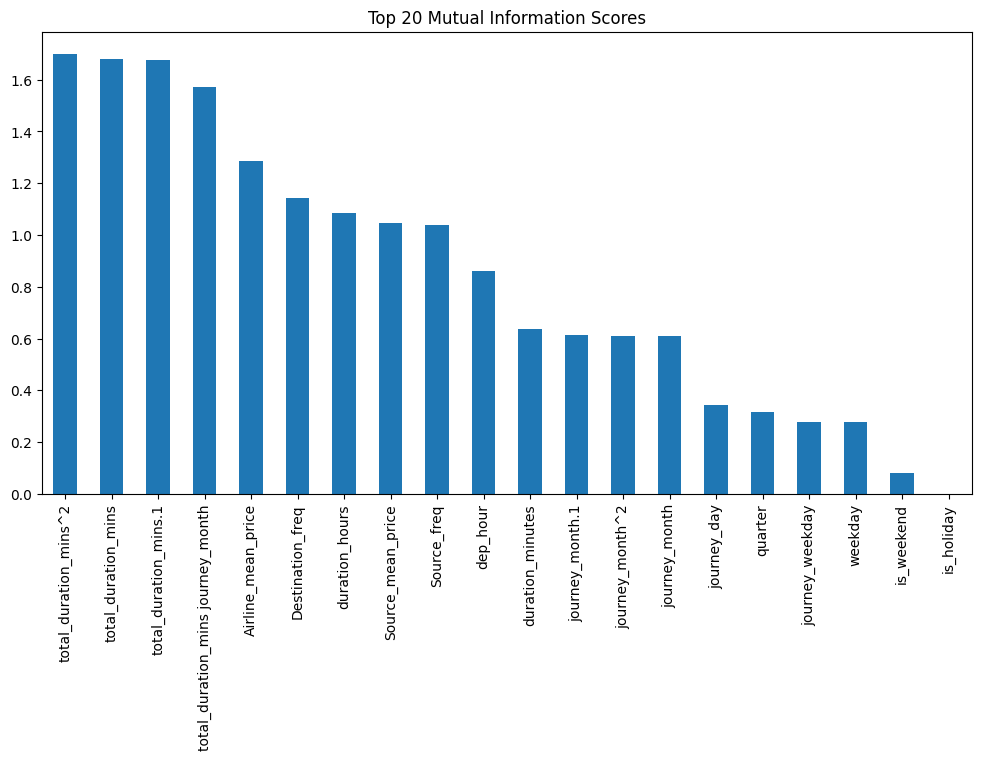

In [ ]:
#Mutual Information
mi_scores = mutual_info_regression(X_train, y_train)

mi_series = pd.Series(mi_scores, index=X.columns)
mi_sorted = mi_series.sort_values(ascending=False)

plt.figure(figsize=(12,6))
mi_sorted.head(20).plot(kind='bar')
plt.title("Top 20 Mutual Information Scores")
plt.show()

###  Graph Insight — Top 20 Mutual Information Scores

- **Pattern:** `Airline_mean_price`, `total_duration_mins`, and `Source_mean_price` consistently rank at the top; polynomial interaction terms and temporal features rank lower.
- **Flight pricing meaning:** The MI scores confirm that airline identity (captured via mean price encoding) contains the most non-linear information about ticket price — consistent with the EDA finding.
- **Model impact:** MI ranking corroborates LASSO selection, strengthening the case for the top 5–8 features being the core predictive set; low-MI features can be dropped without meaningful loss.

---
##  Step: Wrapper Method — Recursive Feature Elimination (RFE)

**Why:** RFE iteratively fits a Random Forest and removes the weakest features, repeating until the target count (10 features) is reached. It is the most computationally expensive but most model-aware selection strategy — it captures feature interactions that embedded and filter methods miss.

TASK 3 – WRAPPER METHOD

In [ ]:
#RFE (Recursive Feature Elimination)
model = RandomForestRegressor(random_state=42)

rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)

selected_rfe = X.columns[rfe.support_]

print("Selected Features by RFE:")
print(selected_rfe)

Selected Features by RFE:
Index(['journey_day', 'journey_month', 'dep_hour', 'duration_hours',
       'total_duration_mins', 'Airline_mean_price', 'total_duration_mins.1',
       'journey_month.1', 'total_duration_mins^2',
       'total_duration_mins journey_month'],
      dtype='object')


---
##  Step: Domain Knowledge Feature Set

**Why:** Beyond algorithmic selection, domain expertise provides a sanity check. Airline mean price, source mean price, total duration, duration hours, and journey month are selected based on aviation pricing logic — these are the variables airlines themselves use in revenue management systems. This set serves as an interpretable baseline that stakeholders can understand and trust.

TASK 4 – CUSTOM DOMAIN SELECTION

In [ ]:
domain_features = [
    'Airline_mean_price',
    'Source_mean_price',
    'total_duration_mins',
    'duration_hours',
    'journey_month'
]

X_train_domain = X_train[domain_features]
X_test_domain = X_test[domain_features]

---
##  Step: Feature Subset Performance Comparison

**Why:** The ultimate validation of feature selection is whether a model trained on the subset performs comparably to one trained on all features. RMSE comparison across Full / LASSO / RFE subsets on the held-out test set determines which selection strategy achieves the best accuracy-vs-complexity trade-off — the winning subset becomes the standard input for Notebooks 6 onwards.

TASK 5 – PERFORMANCE COMPARISON

In [ ]:
#Full Feature Model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_full = rf.predict(X_test)
rmse_full = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_full)))

print("RMSE (All Features):", rmse_full)

RMSE (All Features): 2183.5405006315036


In [ ]:
#LASSO Selected Features
X_train_lasso = X_train[selected_lasso.index]
X_test_lasso = X_test[selected_lasso.index]

rf.fit(X_train_lasso, y_train)
pred_lasso = rf.predict(X_test_lasso)

rmse_lasso = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_lasso)))

print("RMSE (LASSO Features):", rmse_lasso)

RMSE (LASSO Features): 2181.001210029948


In [ ]:
#RFE Selected Features
X_train_rfe = X_train[selected_rfe]
X_test_rfe = X_test[selected_rfe]

rf.fit(X_train_rfe, y_train)
pred_rfe = rf.predict(X_test_rfe)

rmse_rfe = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_rfe)))

print("RMSE (RFE Features):", rmse_rfe)

RMSE (RFE Features): 2241.709537588082


---
##  Next Step → Notebook 05: Data Splitting & Baseline Model

Feature selection is complete. The optimal feature subset (LASSO or RFE-selected, validated by RMSE) will be used as the standard input going forward. **Notebook 05** establishes the baseline model performance — a simple Linear Regression or Decision Tree — that all subsequent advanced models (Random Forest, Gradient Boosting, Stacking) must beat to justify their complexity.